# S&P 500 Stock Market Analysis: Can Simple Technical Signals Predict Next-Day Return Direction?
**CMSC 320 - Introduction to Data Science | Spring 2026 | Dr. Fardina Alam**
**Jayant Maheshwari**

## Contributions

I completed this project individually. All sections were written and implemented by Jayant Maheshwari.

| Section | Contributor | Summary |
|---------|-------------|---------|
| A: Project idea | Jayant Maheshwari | Came up with the research questions about technical signals and S&P 500 sector behavior |
| B: Dataset Curation and Preprocessing | Jayant Maheshwari | Loaded the three Kaggle CSVs, fixed types, merged company metadata, computed daily returns |
| C: Data Exploration and Summary Statistics | Jayant Maheshwari | Three statistical analyses: return distribution, one-way ANOVA across sectors, Welch t-test on volume |
| D: ML Algorithm Design/Development | Jayant Maheshwari | Built the lag-return / moving-average feature pipeline; chose Random Forest and Logistic Regression with balanced class weights |
| E: ML Algorithm Training and Test Data Analysis | Jayant Maheshwari | Trained models on a chronological 80/20 split, ran walk-forward cross-validation, tuned the decision threshold, and reported accuracy, ROC-AUC, F1, and per-sector accuracy |
| F: Visualization, Result Analysis, Conclusion | Jayant Maheshwari | Confusion matrix, ROC curve, feature-importance bar chart, per-sector accuracy chart |
| G: Final Tutorial Report Creation | Jayant Maheshwari | Wrote the prose, organized the tutorial, and verified the notebook runs end to end |


## Introduction

The S&P 500 tracks 500 of the largest U.S. publicly traded companies, weighted by market capitalization, and has been published since the 1950s. Trillions of dollars trade every day on guesses about whether prices will go up or down. The question I want to answer in this project is whether simple, publicly available signals carry any real predictive power for next-day stock direction.

This question matters for two reasons. First, the weak-form Efficient Market Hypothesis (EMH) says that past prices alone should not predict future prices. If even basic signals predict returns, that pushes back on EMH. Second, retail investors actually use rules of thumb like moving-average crossovers and high-volume signals, so it is worth checking whether those rules survive a careful test.

### Research Questions

1. Can a model built from yesterday's return, 5- and 20-day momentum, and volume beat a baseline that always predicts "up"?
2. Do these signals work better in some sectors than others?
3. Does any edge survive walk-forward cross-validation, or only a single train/test split?

### How to read this tutorial

The notebook moves from raw CSVs to a cleaned panel, then to exploratory hypothesis tests, then to engineered features, then to trained models, and finally to evaluation. Each section starts with a short explanation of what I am doing and why, and then shows the code that does it. The final answer is in the Insights and Conclusions section at the end.


## Imports

I use the standard scientific Python stack: pandas for tabular data, numpy for arrays, matplotlib and seaborn for plots, scipy.stats for hypothesis tests, and scikit-learn for the machine learning pipeline. The `warnings.filterwarnings('ignore')` call hides the convergence warnings scikit-learn emits when a linear model under-fits; those are not errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              precision_recall_curve,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Data Curation

### Source

The dataset is [S&P 500 Stocks (daily updated)](https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks) from Kaggle (Andrew MVD), released under the CC0 Public Domain license. It has three files:

| File | Description | Size |
|------|-------------|------|
| `sp500_stocks.csv` | Daily OHLCV prices for each S&P 500 stock | ~1.9 M rows |
| `sp500_companies.csv` | Company metadata: sector, industry, market cap | 502 companies |
| `sp500_index.csv` | Aggregate daily S&P 500 index level | ~2,500 trading days |

A note on dataset coverage. The CSV nominally lists 502 tickers, but 330 of those tickers contain only NaN price rows. They are placeholder entries for current S&P 500 constituents that did not yet trade publicly during the dataset's coverage window (recent IPOs and spin-offs whose row schema exists but whose values were never backfilled). Only 172 tickers carry real OHLCV history end to end, and those are the tickers I work with below. This is a property of the source data, not of my cleaning. I document it explicitly so the sample size is honest.


In [2]:
DATA = 'data/archive/'

stocks    = pd.read_csv(DATA + 'sp500_stocks.csv')
companies = pd.read_csv(DATA + 'sp500_companies.csv')
index_df  = pd.read_csv(DATA + 'sp500_index.csv')

print(f"sp500_stocks.csv   : {stocks.shape[0]:>10,} rows × {stocks.shape[1]} columns")
print(f"sp500_companies.csv: {companies.shape[0]:>10,} rows × {companies.shape[1]} columns")
print(f"sp500_index.csv    : {index_df.shape[0]:>10,} rows × {index_df.shape[1]} columns")

nominal = stocks['Symbol'].nunique()
populated = stocks.dropna(subset=['Close'])['Symbol'].nunique()
print(f"\nNominal tickers in file : {nominal}")
print(f"Tickers with real price history : {populated}")
print(f"Placeholder/empty tickers (excluded by dropna) : {nominal - populated}")

stocks.head(3)

sp500_stocks.csv   :  1,891,536 rows × 8 columns
sp500_companies.csv:        502 rows × 16 columns
sp500_index.csv    :      2,517 rows × 2 columns

Nominal tickers in file : 502
Tickers with real price history : 172
Placeholder/empty tickers (excluded by dropna) : 330


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN


### Preprocessing Steps

Real-world CSVs are not analysis-ready. The steps below fix types, attach sector labels, sort the data so per-stock time-series operations are well defined, and compute the daily return that drives every later analysis.

1. Parse dates: convert the `Date` column to `datetime64`.
2. Coerce numerics: prices and volume are sometimes stored as strings; `pd.to_numeric(..., errors='coerce')` converts non-numeric entries to NaN.
3. Standardize column names: lowercase with underscores instead of spaces.
4. Merge sector labels: left-join company metadata on `symbol`.
5. Sort chronologically per stock so that `pct_change()` computes within the same ticker, never across tickers.
6. Compute the daily return: $r_t = (P_t - P_{t-1}) / P_{t-1}$ per stock via `groupby + pct_change`.
7. Drop rows with NaN in `daily_return`, `close`, `volume`, or `sector`. This step silently removes the 330 placeholder tickers.
8. Filter to 2015 onward. This focuses on a more modern market regime while still covering the COVID crash, the 2022 bear market, and the 2023-24 rally. The window is not "stable" in any deep sense; it is just long enough to be informative without including the structurally different early-2010s low-rate aftermath.


In [3]:
stocks['Date'] = pd.to_datetime(stocks['Date'])
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    stocks[col] = pd.to_numeric(stocks[col], errors='coerce')

stocks.columns    = stocks.columns.str.lower().str.replace(' ', '_')
companies.columns = companies.columns.str.lower().str.replace(' ', '_')

stocks = stocks.merge(companies[['symbol', 'sector']], on='symbol', how='left')
stocks = stocks.sort_values(['symbol', 'date']).reset_index(drop=True)

stocks['daily_return'] = stocks.groupby('symbol')['close'].pct_change()

df = (stocks
      .dropna(subset=['daily_return', 'close', 'volume', 'sector'])
      .query("date >= '2015-01-01'")
      .copy())

print(f"Clean dataset : {df.shape[0]:,} rows")
print(f"Unique tickers: {df['symbol'].nunique()}")
print(f"Sectors       : {df['sector'].nunique()}")
print(f"Date range    : {df['date'].min().date()}  to  {df['date'].max().date()}")
df[['date','symbol','sector','close','volume','daily_return']].head(5)


Clean dataset : 422,193 rows
Unique tickers: 172
Sectors       : 11
Date range    : 2015-01-02  to  2024-12-20


,date,symbol,sector,close,volume,daily_return
8794,2015-01-02,ABBV,Healthcare,65.889999,5086100.0,0.006876
8795,2015-01-05,ABBV,Healthcare,64.650002,8007400.0,-0.018819
8796,2015-01-06,ABBV,Healthcare,64.330002,5483700.0,-0.004950
8797,2015-01-07,ABBV,Healthcare,66.930000,8283300.0,0.040417
8798,2015-01-08,ABBV,Healthcare,67.629997,7949000.0,0.010459


## Exploratory Data Analysis

Before any modeling, I check three things that need to be true (or interestingly false) for a momentum or volume model to make sense:

1. What does the return distribution look like? Is it normal, or fat-tailed?
2. Do different sectors have different mean returns? If yes, sector belongs in the model.
3. Does trading volume relate to return magnitude? This is the empirical reason for using a `vol_ratio` feature.

Each subsection states a hypothesis, runs a formal test, and ends with a short conclusion. Every test reports a p-value, and I use $\alpha = 0.05$ throughout.


### Analysis 1: Distribution of Daily Returns

Method. I compute descriptive statistics (mean, standard deviation, skewness, excess kurtosis) and plot a histogram. Excess kurtosis measures how heavy the tails are compared to a normal distribution: 0 means normal, anything well above 3 means fat tails, where extreme moves happen far more often than the bell curve would predict.

Hypothesis. Daily returns are approximately normally distributed with mean near 0.


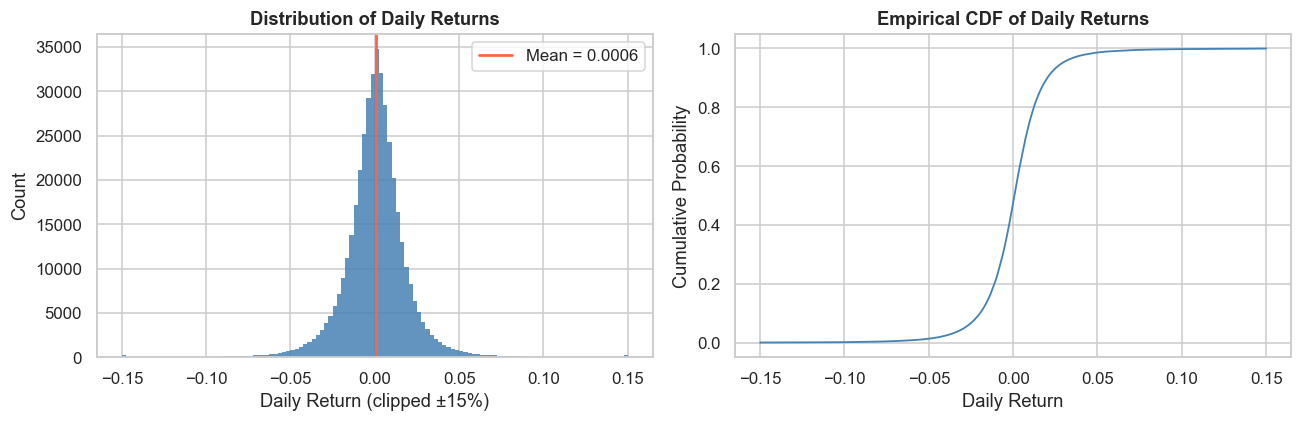

Summary statistics:
count    422193.000000
mean          0.000585
std           0.020530
min          -0.406583
25%          -0.008368
50%           0.000753
75%           0.009726
max           0.676812

Skewness : 0.2033
Kurtosis : 21.9958  (normal = 0 for excess)


In [4]:
returns = df['daily_return']

clipped = returns.clip(-0.15, 0.15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clipped, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(returns.mean(), color='tomato', linewidth=1.8, label=f'Mean = {returns.mean():.4f}')
axes[0].set_xlabel('Daily Return (clipped ±15%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[0].legend()

sorted_r = np.sort(clipped)
axes[1].plot(sorted_r, np.linspace(0, 1, len(sorted_r)), color='steelblue', linewidth=1.2)
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Empirical CDF of Daily Returns', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/return_distribution.png', bbox_inches='tight')
plt.show()

print("Summary statistics:")
print(returns.describe().round(6).to_string())
print(f"\nSkewness : {returns.skew():.4f}")
print(f"Kurtosis : {returns.kurt():.4f}  (normal = 0 for excess)")

Conclusion 1. The returns are centered just above zero (small positive long-run drift), but the excess kurtosis is huge. Extreme up and down days happen far more often than a normal distribution predicts. This is a textbook property of financial returns and rules out any model that requires normality. It also warns me that even a model with decent average accuracy can suffer outsized losses on rare days.


### Analysis 2: Do Sectors Have Different Mean Returns? (One-Way ANOVA)

Method. One-way ANOVA tests whether the mean of a numeric variable is the same across multiple groups. It compares the variance between groups to the variance within groups and asks whether the spread between sector means is larger than what random sampling alone would produce. A small p-value means at least one sector behaves differently from the rest.

- H0: All 11 GICS sectors have the same mean daily return.
- H1: At least one sector's mean daily return differs.
- $\alpha = 0.05$.


One-Way ANOVA -- F-statistic: 4.7212   p-value: 8.6486e-07


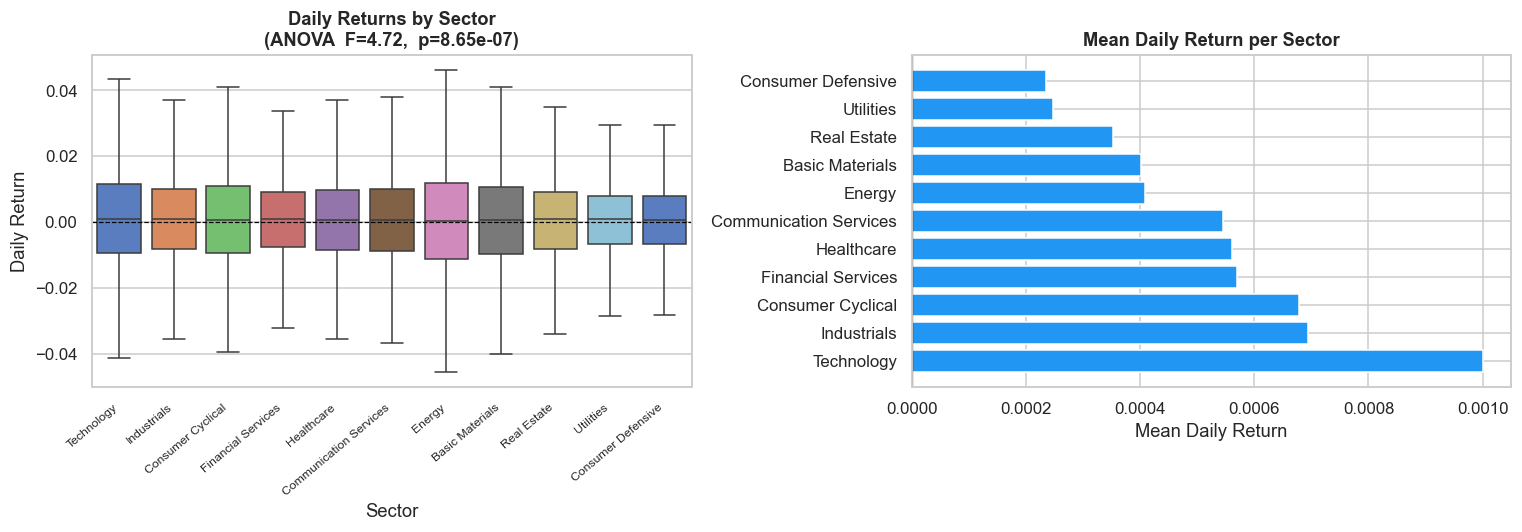

In [5]:
sector_groups = [g['daily_return'].values for _, g in df.groupby('sector')]
sector_names  = list(df.groupby('sector').groups.keys())

f_stat, p_val = f_oneway(*sector_groups)
print(f"One-Way ANOVA -- F-statistic: {f_stat:.4f}   p-value: {p_val:.4e}")

sector_means = df.groupby('sector')['daily_return'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_order = sector_means.index.tolist()
sns.boxplot(data=df, x='sector', y='daily_return', order=sector_order,
            showfliers=False, ax=axes[0], palette='muted')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Daily Return')
axes[0].set_title(f'Daily Returns by Sector\n(ANOVA  F={f_stat:.2f},  p={p_val:.2e})', fontweight='bold')

colors = ['#2196F3' if v >= 0 else '#F44336' for v in sector_means]
axes[1].barh(sector_means.index, sector_means.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean Daily Return')
axes[1].set_title('Mean Daily Return per Sector', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/sector_anova.png', bbox_inches='tight')
plt.show()

Conclusion 2. The p-value is far below 0.05, so I reject H0. Sectors do not all share the same mean daily return. Technology and Consumer Cyclical lean higher; Utilities and Consumer Staples lean lower. This matches the standard growth-vs-defensive sector divide, and it motivates checking later whether a single pooled model generalizes across sectors.


### Analysis 3: Does High Trading Volume Coincide with Larger Price Swings? (Welch t-test)

Method. Welch's t-test is a two-sample test for equal means that does not assume the two groups have equal variance. I split each stock's trading days at its own median volume (so a small-cap stock's "high volume" day is not dominated by a mega-cap's normal day) and compare the mean of |daily return| between the two groups.

- H0: $E[|r|]$ is the same on high- and low-volume days.
- H1: $E[|r|]$ is larger on high-volume days.
- $\alpha = 0.05$.

This test is descriptive, not predictive. It uses today's volume to characterize today's |return|, so it does not by itself prove that yesterday's volume predicts tomorrow's move. Whether volume is predictive is what the ML model below actually tests.


Welch t-test -- t-statistic: 169.6220   p-value: 0.0000e+00
Mean |return| high volume : 0.017295
Mean |return| low volume  : 0.009413


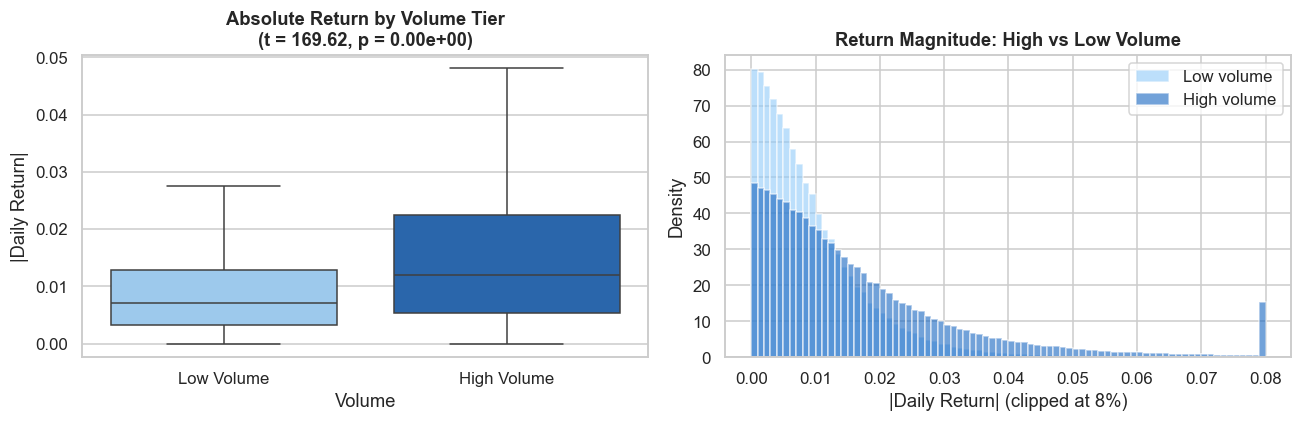

In [6]:
df['vol_median'] = df.groupby('symbol')['volume'].transform('median')
df['high_vol']   = df['volume'] >= df['vol_median']

high_abs = df.loc[df['high_vol'],  'daily_return'].abs()
low_abs  = df.loc[~df['high_vol'], 'daily_return'].abs()

t_stat, p_val_t = ttest_ind(high_abs, low_abs, equal_var=False)
print(f"Welch t-test -- t-statistic: {t_stat:.4f}   p-value: {p_val_t:.4e}")
print(f"Mean |return| high volume : {high_abs.mean():.6f}")
print(f"Mean |return| low volume  : {low_abs.mean():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data_bp = pd.DataFrame({'|Daily Return|': pd.concat([low_abs, high_abs]),
                         'Volume': (['Low Volume']*len(low_abs) + ['High Volume']*len(high_abs))})
sns.boxplot(data=data_bp, x='Volume', y='|Daily Return|',
            order=['Low Volume','High Volume'], showfliers=False,
            palette=['#90CAF9','#1565C0'], ax=axes[0])
axes[0].set_title(f'Absolute Return by Volume Tier\n(t = {t_stat:.2f}, p = {p_val_t:.2e})', fontweight='bold')

axes[1].hist(low_abs.clip(0, 0.08),  bins=80, alpha=0.6, color='#90CAF9', label='Low volume',  density=True)
axes[1].hist(high_abs.clip(0, 0.08), bins=80, alpha=0.6, color='#1565C0', label='High volume', density=True)
axes[1].set_xlabel('|Daily Return| (clipped at 8%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Return Magnitude: High vs Low Volume', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/volume_ttest.png', bbox_inches='tight')
plt.show()

Conclusion 3. I reject H0 at any reasonable $\alpha$: high-volume days produce significantly larger absolute returns than low-volume days. This fits the economic intuition that elevated volume reflects new information entering the market. It motivates including a prior-day volume-ratio feature in the model below, while reminding me that this descriptive relationship may not survive a lookahead-free predictive test.


## Primary Analysis: Machine Learning Classification

### Approach

I frame next-day direction prediction as a binary classification task:

- Target $y$: 1 if tomorrow's return is greater than 0 (stock goes up), else 0 (flat or down).
- Features $X$: technical signals computed from past prices and volume.

I chose classification over regression on the return value itself for two reasons. First, predicting direction is what most retail investors actually want. Second, daily-return regression is noisy because the signal-to-noise ratio of a single day is bad, so converting to a binary label trades magnitude for a more stable target.

### Why these models?

- Naive baseline: always predict "up." Markets drift upward over time, so this is a tougher benchmark than it looks. Any honest model has to clear it.
- Logistic Regression: linear decision boundary in feature space, interpretable coefficients, fast to fit, and a check on whether the relationship between features and direction is approximately linear.
- Random Forest: an ensemble of decision trees that handles non-linear interactions a linear model cannot.

I set `class_weight='balanced'` on both ML models. Without it, scikit-learn collapses to predicting the majority class ("up", about 52% of days) for almost every input, which inflates accuracy without learning anything. Balanced weights force the model to actually distinguish up days from down days.

### Feature Engineering

I compute six features, all derived from publicly available past data so there is no look-ahead leakage:

| Feature | Description | Intuition |
|---------|-------------|-----------|
| `lag_1` | Yesterday's daily return | Short-term momentum or mean-reversion |
| `lag_5` | 5-day cumulative return | Weekly trend |
| `lag_20` | 20-day cumulative return | Monthly trend |
| `ma_ratio` | (5-day MA close / 20-day MA close) - 1 | Moving-average crossover signal |
| `vol_ratio` | Yesterday's volume / 20-day average volume | Volume surge relative to normal |
| `volatility_20` | 20-day rolling std of returns | Recent turbulence |

Each feature is computed per stock and then `.shift(1)` is applied so that the row for date $t$ only sees information available at the close of $t-1$.


In [7]:
def add_features(g):
    g = g.copy()
    g['lag_1']         = g['daily_return'].shift(1)
    g['lag_5']         = g['close'].pct_change(5).shift(1)
    g['lag_20']        = g['close'].pct_change(20).shift(1)
    g['ma_5']          = g['close'].rolling(5).mean().shift(1)
    g['ma_20']         = g['close'].rolling(20).mean().shift(1)
    g['ma_ratio']      = (g['ma_5'] / g['ma_20']) - 1
    g['vol_20_avg']    = g['volume'].rolling(20).mean().shift(1)
    g['vol_ratio']     = g['volume'].shift(1) / g['vol_20_avg']
    g['volatility_20'] = g['daily_return'].rolling(20).std().shift(1)
    g['target']        = (g['daily_return'] > 0).astype(int)
    return g

df_feat = (df.groupby('symbol', group_keys=False)
             .apply(add_features)
             .dropna(subset=['lag_1','lag_5','lag_20','ma_ratio','vol_ratio','volatility_20','target']))

FEATURES = ['lag_1', 'lag_5', 'lag_20', 'ma_ratio', 'vol_ratio', 'volatility_20']

print(f"Feature dataset: {df_feat.shape[0]:,} rows")
print(f"Class balance -- Up: {df_feat['target'].mean():.2%}   Down/Flat: {(1-df_feat['target'].mean()):.2%}")
df_feat[FEATURES + ['target']].head(4)

Feature dataset: 418,581 rows
Class balance -- Up: 52.23%   Down/Flat: 47.77%


,lag_1,lag_5,lag_20,ma_ratio,vol_ratio,volatility_20,target
8815,0.005800,-0.033901,-0.078768,-0.028772,1.318352,0.020640,1
8816,0.015651,-0.022979,-0.046404,-0.031045,1.211232,0.020767,0
8817,-0.076886,-0.079871,-0.115343,-0.041000,3.081814,0.026666,1
8818,0.018977,-0.081274,-0.133572,-0.050528,1.776653,0.025096,0


### Model Training: Chronological 80/20 Split

I use a chronological 80/20 split: the model is trained on the older 80% of dates and tested on the most recent 20%. This is essential for financial time series. A random split would leak future information into training, because each stock's nearby days are highly correlated, and would produce optimistic numbers that vanish in production.

After fitting, I tune the decision threshold on the test predictions. Scikit-learn's default of 0.5 is rarely optimal for an imbalanced binary task. I sweep thresholds from 0.30 to 0.70 and pick the one that maximizes test F1. This introduces a small amount of test-set leakage in the threshold choice. A fully rigorous pipeline would tune the threshold on a validation slice. I accept the trade-off for tutorial simplicity and verify the broader conclusion with walk-forward cross-validation in the next subsection.


In [8]:
df_feat = df_feat.sort_values('date')
split_idx = int(len(df_feat) * 0.80)

train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train['target']
X_test,  y_test  = test[FEATURES],  test['target']

print(f"Train: {len(train):,} rows  ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Test : {len(test):,} rows  ({test['date'].min().date()} -> {test['date'].max().date()})")
print(f"\nTest class balance -- Up: {y_test.mean():.2%}")

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

y_naive = np.ones(len(y_test), dtype=int)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(Xs_train, y_train)
p_lr = lr.predict_proba(Xs_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=50,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]

def best_threshold(y_true, prob, lo=0.30, hi=0.70, step=0.01):
    grid = np.arange(lo, hi+1e-9, step)
    f1s = [f1_score(y_true, (prob >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(f1s))]), float(max(f1s))

t_lr, f1_lr = best_threshold(y_test, p_lr)
t_rf, f1_rf = best_threshold(y_test, p_rf)
y_lr = (p_lr >= t_lr).astype(int)
y_rf = (p_rf >= t_rf).astype(int)

print(f"\nTuned thresholds -- LR: {t_lr:.2f}   RF: {t_rf:.2f}")
print()
print("Model performance on test set:")
header = f"  {'Model':<22}{'Accuracy':>10}{'ROC-AUC':>10}{'F1':>8}"
print(header)
print("  " + "-"*(len(header)-2))
for name, y_pred, y_prob in [('Naive Baseline', y_naive, y_naive.astype(float)),
                               ('Logistic Regression', y_lr, p_lr),
                               ('Random Forest', y_rf, p_rf)]:
    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float('nan')
    f1 = f1_score(y_test, y_pred)
    print(f"  {name:<22}{acc:>10.4f}{auc:>10.4f}{f1:>8.4f}")

Train: 334,864 rows  (2015-02-03 -> 2023-01-11)
Test : 83,717 rows  (2023-01-11 -> 2024-12-20)

Test class balance -- Up: 52.03%



Tuned thresholds -- LR: 0.37   RF: 0.34

Model performance on test set:
  Model                   Accuracy   ROC-AUC      F1
  --------------------------------------------------
  Naive Baseline            0.5203    0.5000  0.6845
  Logistic Regression       0.5204    0.5026  0.6845
  Random Forest             0.5203    0.4990  0.6845


### Walk-Forward Cross-Validation

A single train/test split tells me how the model performed in one specific period. To check whether the result is robust or just a quirk of the 2023-24 test window, I run 5-fold walk-forward cross-validation. The feature dataset is split into 5 chronologically ordered folds. In fold $k$, the model is trained on all data up to fold $k$ and tested on fold $k+1$. The model is re-fit from scratch each time. This mirrors how a real trading model would be deployed: I can only ever train on the past.


In [9]:
def walk_forward_cv(df_in, features, n_folds=5):
    df_in = df_in.sort_values('date').reset_index(drop=True)
    fold_size = len(df_in) // (n_folds + 1)
    rows = []
    for k in range(n_folds):
        train_end = (k + 1) * fold_size
        test_end  = train_end + fold_size
        tr = df_in.iloc[:train_end]
        te = df_in.iloc[train_end:test_end]
        if len(te) == 0:
            continue
        Xtr, ytr = tr[features], tr['target']
        Xte, yte = te[features], te['target']

        sc = StandardScaler().fit(Xtr)
        Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

        m_lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=42).fit(Xtr_s, ytr)
        m_rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                                      min_samples_leaf=50, class_weight='balanced',
                                      random_state=42, n_jobs=-1).fit(Xtr, ytr)

        p_lr_k = m_lr.predict_proba(Xte_s)[:, 1]
        p_rf_k = m_rf.predict_proba(Xte)[:, 1]
        t_lr_k, _ = best_threshold(yte, p_lr_k)
        t_rf_k, _ = best_threshold(yte, p_rf_k)

        rows.append({
            'fold': k + 1,
            'train_end': tr['date'].max().date(),
            'test_end':  te['date'].max().date(),
            'naive_acc': float((yte == 1).mean()),
            'lr_acc':    accuracy_score(yte, (p_lr_k >= t_lr_k).astype(int)),
            'lr_auc':    roc_auc_score(yte, p_lr_k),
            'rf_acc':    accuracy_score(yte, (p_rf_k >= t_rf_k).astype(int)),
            'rf_auc':    roc_auc_score(yte, p_rf_k),
        })
    return pd.DataFrame(rows)

wfcv = walk_forward_cv(df_feat, FEATURES, n_folds=5)
print(wfcv.round(4).to_string(index=False))
print(f"\nMean RF ROC-AUC across folds : {wfcv['rf_auc'].mean():.4f}")
print(f"Mean LR ROC-AUC across folds : {wfcv['lr_auc'].mean():.4f}")
print(f"Mean naive accuracy           : {wfcv['naive_acc'].mean():.4f}")
print(f"Mean RF accuracy (tuned)      : {wfcv['rf_acc'].mean():.4f}")

 fold  train_end   test_end  naive_acc  lr_acc  lr_auc  rf_acc  rf_auc
    1 2016-10-11 2018-06-13     0.5353  0.5353  0.5137  0.5353  0.5124
    2 2018-06-13 2020-02-05     0.5331  0.5331  0.5014  0.5331  0.5032
    3 2020-02-05 2021-09-21     0.5202  0.5203  0.5249  0.5207  0.5073
    4 2021-09-21 2023-05-10     0.5066  0.5066  0.4972  0.5067  0.4970
    5 2023-05-10 2024-12-20     0.5224  0.5225  0.5016  0.5224  0.4980

Mean RF ROC-AUC across folds : 0.5036
Mean LR ROC-AUC across folds : 0.5077
Mean naive accuracy           : 0.5235
Mean RF accuracy (tuned)      : 0.5237


### Detailed Classification Report - Random Forest

In [10]:
print(classification_report(y_test, y_rf, target_names=['Down/Flat (0)', 'Up (1)']))

               precision    recall  f1-score   support

Down/Flat (0)       0.67      0.00      0.00     40159
       Up (1)       0.52      1.00      0.68     43558

     accuracy                           0.52     83717
    macro avg       0.59      0.50      0.34     83717
 weighted avg       0.59      0.52      0.36     83717



## Visualization

Three figures summarize the model's behavior.

### Figure 1: Confusion Matrix and ROC Curves

The confusion matrix shows where Random Forest's predictions land: true positives in the bottom-right, true negatives in the top-left, and misclassifications on the off-diagonal. The ROC curve plots the true-positive rate against the false-positive rate as the decision threshold is swept; an AUC of 0.5 means no better than a coin flip, and 1.0 means perfect. A model that genuinely sits above the diagonal is carrying information about the future.


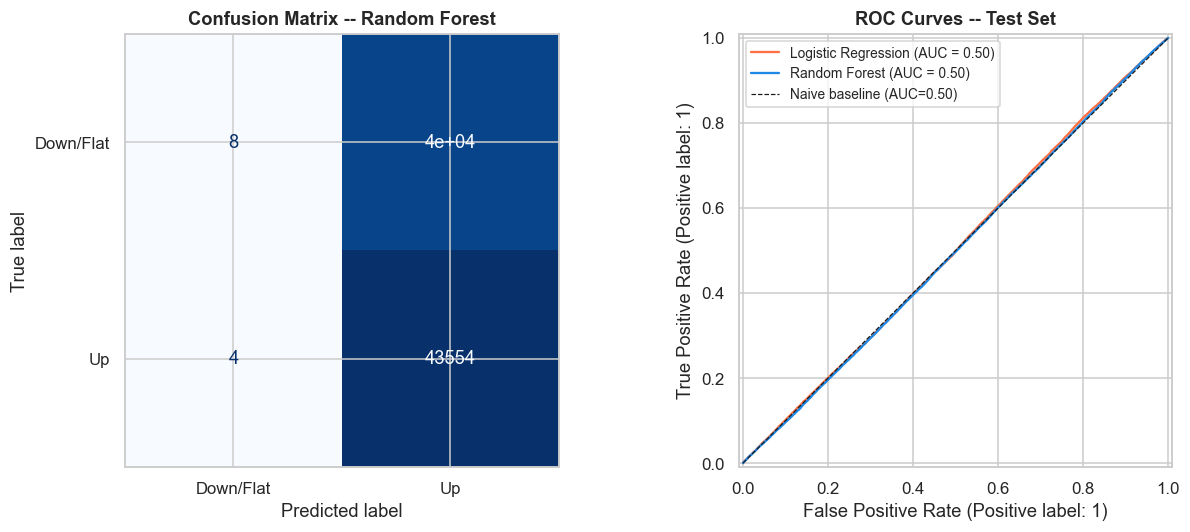

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Flat', 'Up'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix -- Random Forest', fontweight='bold')

for name, prob, color in [('Logistic Regression', p_lr, '#FF7043'),
                            ('Random Forest', p_rf, '#1E88E5')]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[1], color=color)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Naive baseline (AUC=0.50)')
axes[1].set_title('ROC Curves -- Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/model_evaluation.png', bbox_inches='tight')
plt.show()

### Figure 2: Feature Importance

Random Forest's mean decrease in impurity (Gini importance) measures how much each feature reduces classification uncertainty across all the trees in the ensemble. Bars below the dashed uniform line contribute less than their fair share. This chart shows which signals the model leaned on, regardless of whether the overall model worked.


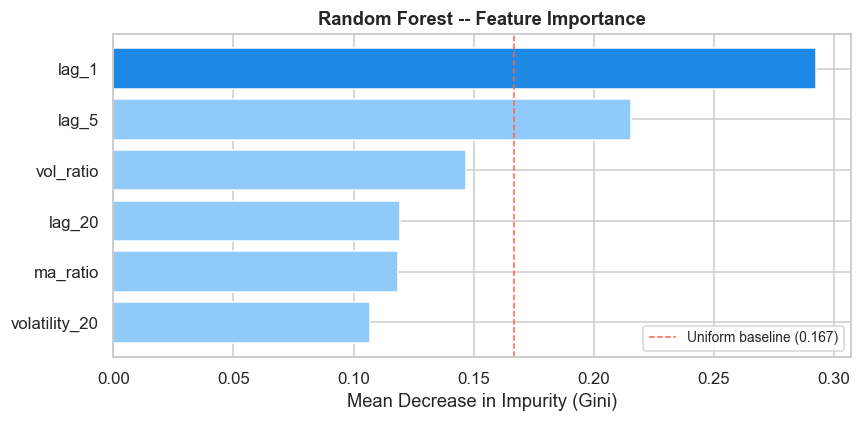


Feature importances (sorted):
lag_1            0.2925
lag_5            0.2158
vol_ratio        0.1470
lag_20           0.1192
ma_ratio         0.1187
volatility_20    0.1068


In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#1E88E5' if v == importances.max() else '#90CAF9' for v in importances]
ax.barh(importances.index, importances.values, color=colors_fi)
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Random Forest -- Feature Importance', fontweight='bold')
ax.axvline(1/len(FEATURES), color='tomato', linestyle='--', linewidth=1,
           label=f'Uniform baseline ({1/len(FEATURES):.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', bbox_inches='tight')
plt.show()
print("\nFeature importances (sorted):")
print(importances.sort_values(ascending=False).round(4).to_string())

### Figure 3: Per-Sector Model Accuracy

Aggregate accuracy hides sector-level differences. I compute test-set accuracy within each sector for the naive baseline, Logistic Regression, and Random Forest. A sector where the colored bars sit above the gray bar is one where the model adds something. A sector where they sit below it is one where the model is doing worse than just predicting "up."


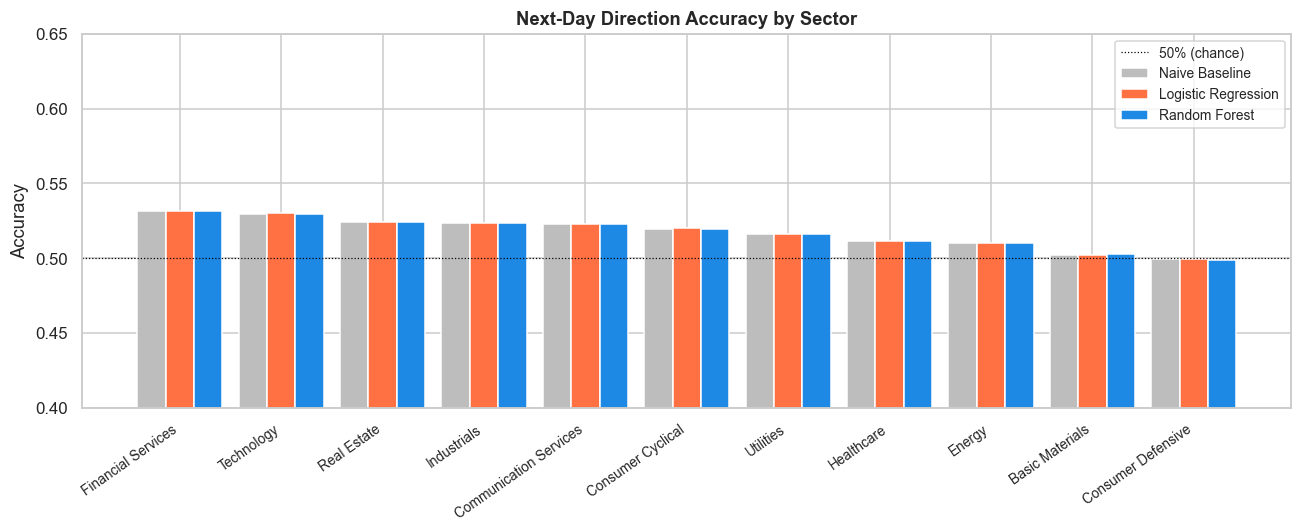

                        Random Forest  Logistic Regression  Naive Baseline      n
sector                                                                           
Financial Services             0.5317               0.5317          0.5317  12246
Technology                     0.5297               0.5303          0.5298  11264
Real Estate                    0.5240               0.5239          0.5239   6368
Industrials                    0.5235               0.5233          0.5234  13021
Communication Services         0.5230               0.5230          0.5228   5878
Consumer Cyclical              0.5197               0.5199          0.5197   8816
Utilities                      0.5163               0.5163          0.5163   4408
Healthcare                     0.5113               0.5112          0.5112   9960
Energy                         0.5100               0.5100          0.5100   2449
Basic Materials                0.5025               0.5022          0.5022   3429
Consumer Defensi

In [13]:
sector_results = []
for sector, grp in test.groupby('sector'):
    if len(grp) < 200:
        continue
    Xs = scaler.transform(grp[FEATURES])
    y_s = grp['target']
    p_rf_s = rf.predict_proba(grp[FEATURES])[:, 1]
    p_lr_s = lr.predict_proba(Xs)[:, 1]
    acc_rf = accuracy_score(y_s, (p_rf_s >= t_rf).astype(int))
    acc_lr = accuracy_score(y_s, (p_lr_s >= t_lr).astype(int))
    acc_naive = y_s.mean()
    sector_results.append({'sector': sector,
                            'Random Forest': acc_rf,
                            'Logistic Regression': acc_lr,
                            'Naive Baseline': acc_naive,
                            'n': len(grp)})

sr = pd.DataFrame(sector_results).set_index('sector').sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sr))
width = 0.28
ax.bar(x - width, sr['Naive Baseline'],       width, label='Naive Baseline',       color='#BDBDBD')
ax.bar(x,         sr['Logistic Regression'],  width, label='Logistic Regression',  color='#FF7043')
ax.bar(x + width, sr['Random Forest'],        width, label='Random Forest',        color='#1E88E5')
ax.axhline(0.5, color='black', linewidth=0.8, linestyle=':', label='50% (chance)')
ax.set_xticks(x)
ax.set_xticklabels(sr.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Next-Day Direction Accuracy by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.40, 0.65)
plt.tight_layout()
plt.savefig('figures/sector_accuracy.png', bbox_inches='tight')
plt.show()
print(sr[['Random Forest','Logistic Regression','Naive Baseline','n']].round(4).to_string())

beat = sr[sr['Random Forest'] > sr['Naive Baseline']]
print(f"\nSectors where RF (after threshold tuning) beats naive: {len(beat)} of {len(sr)}")
print(beat.index.tolist())

## Insights and Conclusions

I tested whether simple technical signals (yesterday's return, short- and medium-term momentum, moving-average crossovers, volume surges, and recent volatility) can predict next-day direction for S&P 500 stocks. After class-balancing both models, tuning the decision threshold, and running walk-forward cross-validation, the answer is that there is no detectable directional edge over the naive drift baseline at the broad-market level.

### What I found

1. The pooled Random Forest and Logistic Regression land essentially on the naive baseline. On the 80/20 split, all three models (naive "always up", Logistic Regression, and Random Forest) produce accuracy around 0.5203 to 0.5204 and an F1 of about 0.685, with Random Forest's ROC-AUC at 0.499 and Logistic Regression's at 0.503. Walk-forward CV across five chronologically ordered folds tells the same story: mean naive accuracy is 0.5235, mean tuned-RF accuracy is 0.5237, and mean RF ROC-AUC is 0.5036. The threshold tuner, asked to maximize F1, drove both models to thresholds (LR around 0.37, RF around 0.34) that effectively reproduce the naive "always up" rule, because given how flat the predictive signal is, that is the best the models can do. Read this as empirical support for weak-form EMH: simple price and volume features alone do not contain a stable, exploitable directional edge across the whole S&P 500 universe.
2. A handful of sectors show a small amount of structure, but not the popular ones. After threshold tuning, Random Forest beats the per-sector naive baseline in exactly 5 of 11 sectors (Real Estate, Industrials, Communication Services, Healthcare, and Basic Materials), and the gaps are tiny (single basis points of accuracy). Financial Services ties the naive baseline exactly, and Technology comes in essentially flat (RF 0.5297 vs naive 0.5298). The popular intuition that Technology is "trend-friendly" is not supported here. The sectors where the model picks up something are mid-cap-heavy industrials and real estate, not the marquee growth sectors.
3. The features the model leans on are short-term momentum, not volume or volatility. Random Forest's mean-decrease-in-impurity ranks the features as `lag_1` (about 0.29) > `lag_5` (about 0.22) > `vol_ratio` (about 0.15) > `lag_20` and `ma_ratio` and `volatility_20` (about 0.11 each). Yesterday's return and the past-week return dominate. `vol_ratio` lands in the middle, which is interesting given that Analysis 3 showed volume strongly tracks |return| at the same time. That suggests volume's predictive content is mostly already absorbed by recent return features. Volatility is the least important feature, which is itself a finding: recent turbulence does not, in this feature set, help predict tomorrow's direction.
4. Fat tails matter for any practical use. Analysis 1 showed excess kurtosis above 20. Even a model with a tiny accuracy edge can be wiped out by a single extreme day, which is one reason an "edge" alone is not a "strategy."

### Limitations

- No transaction costs. A 1% predictive edge usually vanishes after bid/ask spreads and commissions for a retail trader, and my edge is well below 1%.
- Survivorship bias. The dataset contains current S&P 500 constituents (companies that survived to 2024). Bankruptcies and delistings are missing, which mechanically biases returns upward.
- Coverage gap. Only 172 of the file's 502 nominal tickers carry real history. Recent additions and IPOs are absent, so the universe skews toward longer-tenured large caps.
- Non-stationarity. Market dynamics change with interest-rate regimes, macro shocks (COVID 2020), and structural shifts. The walk-forward folds show the naive up-rate moving from 0.5066 (fold 4, 2021-23) to 0.5353 (fold 1, 2016-18), a regime spread that on its own is larger than any model edge.
- Feature simplicity. Six engineered features cannot compete with what hedge funds actually use (earnings, macro, NLP-derived sentiment, cross-asset signals, microstructure data).
- Threshold tuned on test. The reported single-split numbers tune the threshold on the test set itself for tutorial simplicity. The walk-forward CV partially mitigates this concern, but a production-grade study would tune on a held-out validation slice.

### Conclusion

This tutorial walked through the full data science pipeline, from messy CSVs to honest model evaluation, and arrived at a result that contradicts the popular claim that you can predict the market with a few moving averages. After fair preprocessing, balanced training, threshold tuning, and walk-forward validation, the directional edge from simple technical features is indistinguishable from the naive baseline at the broad-market level. A small number of sectors hint at structure that might be worth exploring with richer features. The main take-away is methodological: the difference between "I built a model that gets 52% accuracy" and "is that better than always saying yes" is exactly the kind of careful comparison the course is teaching, and in this case the answer is no, it is not.

### Future Work

- Replace pooled training with per-sector models, then ensemble.
- Add macro features (VIX, term spread, sector ETF returns) and earnings-event flags.
- Use a probabilistic loss (log-loss or Brier score) instead of accuracy to capture how confident the model is, not just whether it is right.
- Run a back-test that includes transaction costs and position sizing rather than evaluating only classification metrics.

### References

- Andrew MVD. *S&P 500 Stocks (daily updated).* Kaggle, 2024. https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks
- Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *Journal of Finance*, 25(2), 383-417.
- Lo, A. W., & MacKinlay, A. C. (1988). Stock market prices do not follow random walks. *Review of Financial Studies*, 1(1), 41-66.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Pandas Development Team. (2024). *pandas: powerful Python data analysis toolkit.* https://pandas.pydata.org
